# 05 — PatchTST: Patch Time-Series Transformer

**Architecture:** PatchTST-style Transformer. The SEQ_LEN lookback is split into non-overlapping
patches; each patch (patch_len × features) is linearly embedded, a CLS token is prepended, and a
Transformer encoder attends over patches. Multi-task heads predict **direction** (Up/Down) and
**forward volatility**. Direction logits are **temperature-scaled** on the validation window for a
calibrated `p(up)`.

**Why this family:** distinct from LGBM (tree), Mamba (SSM), TCN (convolution). Attention over
patches is a demonstrated SOTA approach on financial/TS data and reads window-level structure
rather than reacting bar-by-bar.

**Selective signal:** patching makes predictions window-level (less twitchy), and the asymmetric
`long_signal_threshold` / `short_signal_threshold` grid fires when calibrated confidence clears
0.5 + t — so the model abstains on low-conviction bars instead of trading every hour.

**Label:** Triple Barrier Method (TBM) ±2σ, 24h vertical barrier.
**Splits:** Train ≤ 2022-12-31 · Grid-val 2023-01-01 → 2023-03-31 (3 months) · OOS 2024-06-01 → latest (unified 2-year window).
**Device:** CUDA if available, else MPS, else CPU.

Loads `BTCUSDT_1h_unified.parquet`. Outputs standard artifacts for meta-learning
(`artifacts/notebooks_v2/05_patchtst_v2/`).

In [15]:
import calendar, itertools, json, math, random, time, warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import QuantileTransformer
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

try: plt.style.use('seaborn-v0_8-whitegrid')
except: plt.style.use('seaborn-whitegrid')
mpl.rcParams.update({
    'font.family':'serif','font.serif':['DejaVu Serif'],
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.labelsize':10,'axes.titlesize':11,'xtick.labelsize':9,'ytick.labelsize':9,
    'legend.fontsize':9,'figure.dpi':120,'savefig.dpi':200,'savefig.bbox':'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'; RED='#EF5350'; GREEN='#26A69A'

if torch.cuda.is_available():    DEVICE=torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built(): DEVICE=torch.device('mps')
else: DEVICE=torch.device('cpu')

def _repo_root():
    p=Path.cwd()
    while p!=p.parent:
        if (p/'pyproject.toml').exists(): return p
        p=p.parent
    raise RuntimeError('pyproject.toml not found — run from inside the repo')

REPO     = _repo_root()
ARTS_DIR = REPO/'artifacts'/'notebooks_v2'/'05_patchtst_v2'
ARTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Device  : {DEVICE}')
print(f'Artifacts → {ARTS_DIR}')


Device  : mps
Artifacts → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/notebooks_v2/05_patchtst_v2


In [16]:
# ── WFO cadence ────────────────────────────────────────────────────────────────
BASE_TRAIN_END  = pd.Timestamp('2022-12-31')
OOS_REF_START   = pd.Timestamp('2024-06-01')   # for oos_probs subset (matches v1)
FOLD_VAL_MONTHS = 3
FOLD_OOS_MONTHS = 3

TBM_VOL_WINDOW=24; TBM_MULT=2.0; TBM_VERT_H=24
FRAC_D=0.4; FFD_THRES=1e-4
SEQ_LEN=48

PATCH_LEN=8; PATCH_STRIDE=4
D_MODEL=64; N_HEADS=4; N_LAYERS=2; D_FF=128; TR_DROPOUT=0.20
EPOCHS=80; BATCH_SIZE=256; LR=3e-4; WEIGHT_DECAY=1e-4
PATIENCE=15; LAMBDA_VOL=0.50; AUX_FWD_H=6

MAKER_FEE=0.0000; SPOT_TAKER_FEE=0.0005; FUTURES_TAKER_FEE=0.0005
BUFFER=0.0005; SHORT_FUNDING_H=0.0000077; MIN_SL=0.010

LGBM_CORE=['stoch_k_14','ret_2h','rsi_divergence','close_vs_sma_7','bear_streak',
           'close_vs_s1','macd_hist_5_13','ad_z_48h','ret_3h']
V1_EXTRA=['ret_1h','rsi_14','vol_ratio_24h','bb_position_20','hour_sin','hour_cos',
          'atr_14_pct','hurst_168h','trend_score','close_vs_sma_50','ma_bull_score']
V4_FEATURES=['close_vs_true_vwap','hurst_24h','hurst_72h','tfi_pct','tfi_z_24h',
             'bb_width_pct','sideways_flag']
STRUCT_FEATURES=['liq_vwap_dev_24h','volat_atr_20_pct','mtf_alignment','mtf_h4_rsi']
BASE_FEATURES=LGBM_CORE+V1_EXTRA+V4_FEATURES+STRUCT_FEATURES

TRADING_GRID={
    'long_signal_threshold': [0.03, 0.05, 0.06, 0.08, 0.10, 0.13, 0.15, 0.18],
    'short_signal_threshold':[0.03, 0.05, 0.06, 0.08, 0.10, 0.13, 0.15, 0.18],
    'entry_atr_mult': [0.0,0.3,0.6],
    'sl_atr_mult':    [1.5,2.0,2.5],
    'tp_atr_mult':    [2.0,2.5,3.0],
    'min_hold':       [6,12],
    'max_hold':       [24,48],
    'cooldown':       [2,3],
}
_all_combos=list(itertools.product(*TRADING_GRID.values()))
_grid_keys=list(TRADING_GRID)
MAX_TRADES_GRID=80; MIN_TRADES_GRID=5
N_PATCHES=(SEQ_LEN-PATCH_LEN)//PATCH_STRIDE+1
print(f'Device={DEVICE}  fold={FOLD_VAL_MONTHS}m val / {FOLD_OOS_MONTHS}m OOS  grid={len(_all_combos):,} combos')


Device=mps  fold=3m val / 3m OOS  grid=13,824 combos


## 1 · Load data

In [17]:

UNIFIED=REPO/'data'/'features'/'BTCUSDT_1h_unified.parquet'
if not UNIFIED.exists():
    raise FileNotFoundError(f'{UNIFIED} not found — run 00_data_ingestion_v1.ipynb first.')

df=pd.read_parquet(UNIFIED)
df.index=df.index.tz_localize(None) if df.index.tz else df.index

missing=[f for f in BASE_FEATURES if f not in df.columns]
if missing: print(f'WARNING — missing: {missing}')
else: print(f'All {len(BASE_FEATURES)} base features present.')
print(f'Shape: {df.shape}  ({df.index.min().date()} → {df.index.max().date()})')


All 31 base features present.
Shape: (77013, 292)  (2017-08-17 → 2026-05-31)


## 2 · Fractional differentiation

In [18]:

log_close=np.log(df['close'])

def _ffd_weights(d,thres=1e-4):
    w=[1.0]; k=1
    while True:
        w_k=-w[-1]*(d-k+1)/k; w.append(w_k)
        if abs(w_k)<thres: break
    return np.array(w[::-1])

def _ffd_series(series,d,thres=1e-4):
    w=_ffd_weights(d,thres); n_w=len(w); n=len(series)
    out=np.full(n,np.nan)
    for i in range(n_w-1,n):
        out[i]=float(np.dot(w,series.iloc[i-n_w+1:i+1].values))
    return pd.Series(out,index=series.index,name=f'ffd_{d}')

ffd_col='ffd_log_price'
df[ffd_col]=_ffd_series(log_close,FRAC_D,FFD_THRES)
print(f'FFD d={FRAC_D}: {df[ffd_col].notna().sum():,} valid bars  '
      f'(first valid: {df[ffd_col].dropna().index[0].date()})')


FFD d=0.4: 77,002 valid bars  (first valid: 2017-08-17)


## 3 · TBM labels

In [19]:

log_rets=log_close.diff()
rolling_vol=log_rets.rolling(TBM_VOL_WINDOW).std()
close_vals=df['close'].values; vol_vals=rolling_vol.values; n=len(df)

y_dir=np.full(n,np.nan,dtype=np.float32)
y_fwd_vol=np.full(n,np.nan,dtype=np.float32)
t0_=time.time()
for i in range(n):
    if np.isnan(vol_vals[i]) or vol_vals[i]==0: continue
    sigma=vol_vals[i]*close_vals[i]
    up=close_vals[i]+TBM_MULT*sigma; dn=close_vals[i]-TBM_MULT*sigma
    end_j=min(i+TBM_VERT_H,n)
    for j in range(i+1,end_j):
        if close_vals[j]>=up:   y_dir[i]=1; break
        if close_vals[j]<=dn:   y_dir[i]=0; break
    else: y_dir[i]=-1  # -1 = vertical timeout
    fwd=log_rets.iloc[i+1:i+1+AUX_FWD_H].values
    if len(fwd): y_fwd_vol[i]=float(np.std(fwd))

df['y_dir']    =y_dir
df['y_fwd_vol']=y_fwd_vol
valid_dir=np.array([v in (0,1) for v in y_dir])
print(f'TBM done in {time.time()-t0_:.0f}s  |  Up={int((y_dir==1).sum()):,}  '
      f'Down={int((y_dir==0).sum()):,}  Timeout={int((y_dir==-1).sum()):,}  '
      f'NaN={int(np.isnan(y_dir).sum()):,}')


TBM done in 1s  |  Up=34,694  Down=33,182  Timeout=9,103  NaN=34


## 4 · WFO fold definitions

In [20]:
ALL_FEATURES = BASE_FEATURES + [ffd_col]

folds = []
cursor = BASE_TRAIN_END
while True:
    val_start = cursor + pd.Timedelta(hours=1)
    val_end   = val_start + pd.DateOffset(months=FOLD_VAL_MONTHS) - pd.Timedelta(hours=1)
    oos_start = val_end   + pd.Timedelta(hours=1)
    oos_end   = oos_start + pd.DateOffset(months=FOLD_OOS_MONTHS) - pd.Timedelta(hours=1)
    if oos_end > df.index[-1]: break
    folds.append(dict(fold=len(folds)+1, train_end=cursor,
                      val_start=val_start, val_end=val_end,
                      oos_start=oos_start, oos_end=oos_end))
    cursor = val_end   # training expands by one val period each fold

print(f'{len(folds)} WFO folds:')
for f in folds:
    print(f"  Fold {f['fold']:>2}: train≤{f['train_end'].date()}  "
          f"val {f['val_start'].date()}→{f['val_end'].date()}  "
          f"OOS {f['oos_start'].date()}→{f['oos_end'].date()}")


12 WFO folds:
  Fold  1: train≤2022-12-31  val 2022-12-31→2023-03-31  OOS 2023-03-31→2023-06-30
  Fold  2: train≤2023-03-31  val 2023-03-31→2023-06-30  OOS 2023-06-30→2023-09-30
  Fold  3: train≤2023-06-30  val 2023-06-30→2023-09-30  OOS 2023-09-30→2023-12-30
  Fold  4: train≤2023-09-30  val 2023-09-30→2023-12-30  OOS 2023-12-30→2024-03-30
  Fold  5: train≤2023-12-30  val 2023-12-30→2024-03-30  OOS 2024-03-30→2024-06-30
  Fold  6: train≤2024-03-30  val 2024-03-30→2024-06-30  OOS 2024-06-30→2024-09-30
  Fold  7: train≤2024-06-30  val 2024-06-30→2024-09-30  OOS 2024-09-30→2024-12-30
  Fold  8: train≤2024-09-30  val 2024-09-30→2024-12-30  OOS 2024-12-30→2025-03-30
  Fold  9: train≤2024-12-30  val 2024-12-30→2025-03-30  OOS 2025-03-30→2025-06-30
  Fold 10: train≤2025-03-30  val 2025-03-30→2025-06-30  OOS 2025-06-30→2025-09-30
  Fold 11: train≤2025-06-30  val 2025-06-30→2025-09-30  OOS 2025-09-30→2025-12-30
  Fold 12: train≤2025-09-30  val 2025-09-30→2025-12-30  OOS 2025-12-30→2026-03-30


## 5 · Helper: make_seqs

In [21]:
def make_seqs(X, y_d, y_v, seq_len):
    Xs=[]; Yd=[]; Yv=[]
    for i in range(seq_len-1, len(X)):
        yd=y_d[i]; yv=y_v[i]
        if yd not in (0,1): continue
        Xs.append(X[i-seq_len+1:i+1]); Yd.append(int(yd))
        Yv.append(yv if not np.isnan(yv) else 0.0)
    return (np.stack(Xs).astype(np.float32),
            np.array(Yd, dtype=np.int64),
            np.array(Yv, dtype=np.float32))

print('make_seqs ready.')


make_seqs ready.


## 6 · PatchTST model

In [22]:

class PatchTST(nn.Module):
    """Patch-based Transformer. Lookback -> patches -> linear embed -> CLS+pos ->
    TransformerEncoder -> multi-task heads (direction logits + forward-vol)."""
    def __init__(self, n_feat, seq_len, patch_len, stride, d_model, n_heads,
                 n_layers, d_ff, dropout, n_classes=2):
        super().__init__()
        self.patch_len=patch_len; self.stride=stride
        self.n_patches=(seq_len-patch_len)//stride+1
        self.proj=nn.Linear(patch_len*n_feat, d_model)
        self.cls=nn.Parameter(torch.randn(1,1,d_model)*0.02)
        self.pos=nn.Parameter(torch.randn(1,self.n_patches+1,d_model)*0.02)
        self.in_drop=nn.Dropout(dropout)
        enc=nn.TransformerEncoderLayer(d_model, n_heads, d_ff, dropout,
                                       activation='gelu', batch_first=True, norm_first=True)
        self.encoder=nn.TransformerEncoder(enc, n_layers)
        self.norm=nn.LayerNorm(d_model)
        self.head_drop=nn.Dropout(dropout)
        self.cls_head=nn.Linear(d_model, n_classes)
        self.vol_head=nn.Linear(d_model, 1)
    def forward(self, x):                          # x: (B, T, F)
        B,T,Fd=x.shape
        patches=x.unfold(1, self.patch_len, self.stride)   # (B, n_patches, F, patch_len)
        patches=patches.permute(0,1,3,2).reshape(B, self.n_patches, self.patch_len*Fd)
        h=self.in_drop(self.proj(patches))                 # (B, n_patches, d_model)
        cls=self.cls.expand(B,-1,-1)
        h=torch.cat([cls,h],dim=1)+self.pos                # (B, n_patches+1, d_model)
        h=self.encoder(h)
        pooled=self.head_drop(self.norm(h.mean(dim=1)))    # mean-pool all tokens
        return self.cls_head(pooled), self.vol_head(pooled).squeeze(-1)

model=PatchTST(N_FEATURES, SEQ_LEN, PATCH_LEN, PATCH_STRIDE, D_MODEL, N_HEADS,
               N_LAYERS, D_FF, TR_DROPOUT).to(DEVICE)
n_params=sum(p.numel() for p in model.parameters())
print(f'PatchTST: {n_params:,} params  |  in_features={N_FEATURES}  patches={model.n_patches}')

PatchTST: 84,547 params  |  in_features=32  patches=11


## 7 · Backtest engine & regime helpers

In [23]:
def _run_backtest(probs_arr, pdown_arr, close_arr, high_arr, low_arr, atr_arr,
        long_threshold, short_threshold, entry_atr_mult, sl_atr_mult, tp_atr_mult,
        min_hold, max_hold, cooldown, with_fees=True):
    n=len(close_arr); eq=np.ones(n); cur=1.0; trades=[]
    in_pos=False; direction=None; entry_px=sl_px=tp_px=pos_eq=entry_fee=0.0
    hold_cnt=cd_cnt=0; funding=0.0; pending=None
    for i in range(n):
        lo=low_arr[i]; hi=high_arr[i]; px=close_arr[i]
        if in_pos:
            hold_cnt+=1
            if direction=='short': funding+=SHORT_FUNDING_H
            eq[i]=pos_eq*(px/entry_px if direction=='long' else 1+(entry_px-px)/entry_px)
            exited=False; exit_px=0.; reason=''; exit_fee=0.
            if hold_cnt>=min_hold:
                if direction=='long':
                    if lo<=sl_px: exit_px=sl_px;exited=True;reason='sl';exit_fee=SPOT_TAKER_FEE if with_fees else 0.
                    elif hi>=tp_px: exit_px=tp_px;exited=True;reason='tp';exit_fee=MAKER_FEE
                    elif hold_cnt>=max_hold: exit_px=px;exited=True;reason='timeout';exit_fee=SPOT_TAKER_FEE if with_fees else 0.
                else:
                    if hi>=sl_px: exit_px=sl_px;exited=True;reason='sl';exit_fee=FUTURES_TAKER_FEE if with_fees else 0.
                    elif lo<=tp_px: exit_px=tp_px;exited=True;reason='tp';exit_fee=MAKER_FEE
                    elif hold_cnt>=max_hold: exit_px=px;exited=True;reason='timeout';exit_fee=FUTURES_TAKER_FEE if with_fees else 0.
            if exited:
                gross=((exit_px-entry_px)/entry_px if direction=='long' else (entry_px-exit_px)/entry_px)
                net=gross-(entry_fee+exit_fee if with_fees else 0.)+funding
                cur=pos_eq*(1.+net); eq[i]=cur
                trades.append({'direction':direction,'reason':reason,'gross':gross,'net':net,'hold':hold_cnt})
                in_pos=False; cd_cnt=cooldown; funding=0.
        elif pending is not None:
            d,lim,p_sl,p_tp=pending
            if d=='long': filled=lo<=lim+BUFFER; ef=MAKER_FEE if (filled and with_fees) else (SPOT_TAKER_FEE if with_fees else 0.)
            else: filled=hi>=lim-BUFFER; ef=MAKER_FEE if (filled and with_fees) else (FUTURES_TAKER_FEE if with_fees else 0.)
            entry_px=lim if filled else px; sl_px=p_sl; tp_px=p_tp; entry_fee=ef
            direction=d; in_pos=True; pos_eq=cur; hold_cnt=0; funding=0.; pending=None; eq[i]=cur
        elif cd_cnt>0: cd_cnt-=1; eq[i]=cur
        elif i+1<n:
            atr=max(atr_arr[i],MIN_SL)
            if probs_arr[i]>long_threshold:
                pending=('long',px*(1-entry_atr_mult*atr),px*(1-sl_atr_mult*atr),px*(1+tp_atr_mult*atr))
            elif pdown_arr[i]>short_threshold:
                pending=('short',px*(1+entry_atr_mult*atr),px*(1+sl_atr_mult*atr),px*(1-tp_atr_mult*atr))
            eq[i]=cur
        else: eq[i]=cur
    if in_pos:
        gross=((px-entry_px)/entry_px if direction=='long' else (entry_px-px)/entry_px)
        taker=SPOT_TAKER_FEE if direction=='long' else FUTURES_TAKER_FEE
        net=gross-(entry_fee+(taker if with_fees else 0.))+funding; cur=pos_eq*(1.+net); eq[-1]=cur
    return eq, trades

def _sharpe(eq):
    r=np.diff(np.log(np.maximum(eq,1e-12))); return float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(24*365))
def _maxdd(eq):
    pk=np.maximum.accumulate(eq); return float(((eq-pk)/(pk+1e-12)).min())
def _sortino(eq):
    r=np.diff(np.log(np.maximum(eq,1e-12))); neg=r[r<0]
    d=neg.std(ddof=1) if len(neg)>1 else 1e-12
    return float(r.mean()/(d+1e-12)*np.sqrt(24*365))

REGIME_CHOP = (pd.Timestamp('2024-06-01'), pd.Timestamp('2024-11-05'))
REGIME_BULL = (pd.Timestamp('2024-11-06'), pd.Timestamp('2025-10-31'))
REGIME_BEAR = (pd.Timestamp('2025-11-01'), pd.Timestamp('2026-05-31'))

def _regime_table(eq_arr, idx, close_arr):
    eq_s=pd.Series(eq_arr,index=idx); cl_s=pd.Series(close_arr,index=idx); rows=[]
    for label,(s,e) in [('Full WFO OOS',(idx.min(),idx.max())),
                         ('Regime 1 — Chop',REGIME_CHOP),
                         ('Regime 2 — Bull',REGIME_BULL),
                         ('Regime 3 — Bear',REGIME_BEAR)]:
        m=(idx>=s)&(idx<=e)
        if m.sum()<24: continue
        seg=eq_s[m].values/eq_s[m].values[0]; bh=cl_s[m].values/cl_s[m].values[0]
        pk=np.maximum.accumulate(seg); dd=float(((seg-pk)/(pk+1e-12)).min())
        rows.append({'Period':label,'Bars':int(m.sum()),
                     'Return':f'{seg[-1]-1:+.1%}','Sharpe':f'{_sharpe(seg):.3f}',
                     'Sortino':f'{_sortino(seg):.3f}','MaxDD':f'{dd:.1%}',
                     'BH_Ret':f'{bh[-1]-1:+.1%}','Alpha':f'{seg[-1]-bh[-1]:+.1%}'})
    return pd.DataFrame(rows).set_index('Period')

print('Backtest engine + regime helpers ready.')


Backtest engine + regime helpers ready.


## 8 · WFO main loop

In [24]:
wfo_results = []
t_wfo = time.time()

for fd in folds:
    fn = fd['fold']
    print(f"\n── Fold {fn:>2} ── train≤{fd['train_end'].date()}  "
          f"val {fd['val_start'].date()}→{fd['val_end'].date()}  "
          f"OOS {fd['oos_start'].date()}→{fd['oos_end'].date()}")

    # ── masks
    tr_mask  = (df.index <= fd['train_end']) & valid_dir & df[ALL_FEATURES].notna().all(axis=1)
    val_mask = ((df.index >= fd['val_start']) & (df.index <= fd['val_end'])
                & valid_dir & df[ALL_FEATURES].notna().all(axis=1))
    df_tr = df[tr_mask].copy(); df_vl = df[val_mask].copy()

    # ── normalise (fit on train only)
    qt = QuantileTransformer(output_distribution='normal',
                             n_quantiles=min(1000, len(df_tr)), random_state=SEED)
    X_tr = qt.fit_transform(np.nan_to_num(df_tr[ALL_FEATURES].values.astype(np.float32))).astype(np.float32)
    X_vl = qt.transform(np.nan_to_num(df_vl[ALL_FEATURES].values.astype(np.float32))).astype(np.float32)

    # ── sequences
    X_tr_s, y_tr_d, y_tr_v = make_seqs(X_tr, df_tr['y_dir'].values, df_tr['y_fwd_vol'].values, SEQ_LEN)
    X_vl_s, y_vl_d, y_vl_v = make_seqs(X_vl, df_vl['y_dir'].values, df_vl['y_fwd_vol'].values, SEQ_LEN)
    N_FEATURES = X_tr_s.shape[2]
    print(f'  train={len(X_tr_s):,}  val={len(X_vl_s):,}  feat={N_FEATURES}')
    if len(X_vl_s) < 50:
        print('  SKIP: val too small'); continue

    # ── fresh model
    model = PatchTST(N_FEATURES, SEQ_LEN, PATCH_LEN, PATCH_STRIDE,
                     D_MODEL, N_HEADS, N_LAYERS, D_FF, TR_DROPOUT).to(DEVICE)

    # ── train
    counts = np.bincount(y_tr_d, minlength=2)
    w = torch.tensor(1.0/counts, dtype=torch.float32).to(DEVICE); w /= w.sum()
    cls_crit = nn.CrossEntropyLoss(weight=w); vol_crit = nn.MSELoss()
    ld_tr = DataLoader(TensorDataset(torch.from_numpy(X_tr_s), torch.from_numpy(y_tr_d),
                                     torch.from_numpy(y_tr_v)), BATCH_SIZE, shuffle=True, drop_last=True)
    ld_vl = DataLoader(TensorDataset(torch.from_numpy(X_vl_s), torch.from_numpy(y_vl_d),
                                     torch.from_numpy(y_vl_v)), BATCH_SIZE, shuffle=False)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = OneCycleLR(opt, max_lr=LR, epochs=EPOCHS, steps_per_epoch=len(ld_tr))

    best_vl=1e9; best_state=None; best_epoch=0; va=0.
    for ep in range(1, EPOCHS+1):
        model.train(); tl=0.
        for xb,yd,yv in ld_tr:
            xb=xb.to(DEVICE); yd=yd.to(DEVICE); yv=yv.to(DEVICE)
            opt.zero_grad()
            logits,vp=model(xb)
            loss=cls_crit(logits,yd)+LAMBDA_VOL*vol_crit(vp,yv)
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step(); sched.step()
            tl+=loss.item()
        tl/=len(ld_tr)
        model.eval(); vl=0.; ps=[]; ys=[]
        with torch.no_grad():
            for xb,yd,yv in ld_vl:
                xb=xb.to(DEVICE); yd=yd.to(DEVICE); yv=yv.to(DEVICE)
                logits,vp=model(xb)
                vl+=(cls_crit(logits,yd)+LAMBDA_VOL*vol_crit(vp,yv)).item()
                ps.append(torch.softmax(logits,-1)[:,1].cpu().numpy()); ys.append(yd.cpu().numpy())
        vl/=len(ld_vl); va=roc_auc_score(np.concatenate(ys),np.concatenate(ps))
        if vl<best_vl:
            best_vl=vl; best_epoch=ep
            best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}
        if ep-best_epoch>=PATIENCE: break
    model.load_state_dict(best_state)
    print(f'  trained: best_ep={best_epoch}  val_loss={best_vl:.5f}  val_auc={va:.4f}')

    # ── temperature scaling
    model.eval(); _lg=[]; _ly=[]
    with torch.no_grad():
        for xb,yd,yv in ld_vl:
            lg,_=model(xb.to(DEVICE)); _lg.append(lg.cpu()); _ly.append(yd)
    _lg=torch.cat(_lg); _ly=torch.cat(_ly)
    _T=torch.ones(1, requires_grad=True)
    _opt_t=torch.optim.LBFGS([_T], lr=0.05, max_iter=200)
    _nll=nn.CrossEntropyLoss()
    def _tc():
        _opt_t.zero_grad(); loss=_nll(_lg/_T.clamp(min=1e-2),_ly); loss.backward(); return loss
    _opt_t.step(_tc)
    temp=float(_T.detach().clamp(min=1e-2))

    # ── val inference for grid
    pre_val_df = df[(df.index >= fd['val_start']-pd.Timedelta(hours=SEQ_LEN))
                    & (df.index <= fd['val_end'])].copy()
    Xv_ = qt.transform(np.nan_to_num(pre_val_df[ALL_FEATURES].values.astype(np.float32)))
    model.eval(); vp_list=[]; vd_list=[]
    with torch.no_grad():
        for i in range(SEQ_LEN-1, len(Xv_)):
            xb=torch.from_numpy(Xv_[i-SEQ_LEN+1:i+1][None]).to(DEVICE)
            logits,_=model(xb); p=torch.softmax(logits/temp,-1).cpu().numpy()[0]
            vp_list.append(p); vd_list.append(pre_val_df.index[i])
    vp_arr=np.array(vp_list,dtype=np.float32); vp_up=vp_arr[:,1]; vp_dn=vp_arr[:,0]
    val_df_bt=df.loc[vd_list].copy()

    # ── grid search
    rows=[]
    for vals in _all_combos:
        p=dict(zip(_grid_keys,vals))
        if p['max_hold']<p['min_hold']: continue
        if p['long_signal_threshold']==p['short_signal_threshold']: continue
        lt=0.5+p['long_signal_threshold']; st=0.5+p['short_signal_threshold']
        p_bt={k:v for k,v in p.items() if k not in ('long_signal_threshold','short_signal_threshold')}
        p_bt['long_threshold']=lt; p_bt['short_threshold']=st
        eq,tr=_run_backtest(vp_up,vp_dn,val_df_bt['close'].values,val_df_bt['high'].values,
                            val_df_bt['low'].values,val_df_bt['atr_14_pct'].values,with_fees=True,**p_bt)
        if len(tr)<MIN_TRADES_GRID or len(tr)>MAX_TRADES_GRID: continue
        rows.append({**p_bt,'sharpe':_sharpe(eq),'total_ret':float(eq[-1]-1),'n_trades':len(tr)})
    if not rows:
        print('  WARN: grid 0 combos, skipping'); continue
    grid_df=pd.DataFrame(rows).sort_values('sharpe',ascending=False)
    INT={'min_hold','max_hold','cooldown'}
    best={k:(int(grid_df.iloc[0][k]) if k in INT else float(grid_df.iloc[0][k]))
          for k in ['long_threshold','short_threshold','entry_atr_mult','sl_atr_mult','tp_atr_mult','min_hold','max_hold','cooldown']}
    print(f'  grid: {len(grid_df):,} combos  best_sharpe={grid_df.iloc[0]["sharpe"]:.3f}  '
          f'lt={best["long_threshold"]:.2f}  st={best["short_threshold"]:.2f}')
    assert best['long_threshold']!=best['short_threshold'],'BUG: thresholds equal'

    # ── OOS inference
    pre_oos_df=df[(df.index>=fd['oos_start']-pd.Timedelta(hours=SEQ_LEN-1))
                  & (df.index<=fd['oos_end'])].copy()
    X_pre=qt.transform(np.nan_to_num(pre_oos_df[ALL_FEATURES].values.astype(np.float32)))
    model.eval(); oos_full=[]; oos_idx_=[]
    with torch.no_grad():
        for i in range(SEQ_LEN-1,len(X_pre)):
            xb=torch.from_numpy(X_pre[i-SEQ_LEN+1:i+1][None]).to(DEVICE)
            logits,_=model(xb); p=torch.softmax(logits/temp,-1).cpu().numpy()[0]
            oos_full.append(p); oos_idx_.append(pre_oos_df.index[i])
    oos_full=np.array(oos_full,dtype=np.float32)
    trim=np.array(oos_idx_)>=fd['oos_start']
    oos_pup_=oos_full[trim,1]; oos_pdn_=oos_full[trim,0]
    oos_idx_arr=np.array(oos_idx_)[trim]
    oos_plot=df.loc[oos_idx_arr].copy()

    # ── OOS backtest
    eq_fees,tdf=_run_backtest(oos_pup_,oos_pdn_,oos_plot['close'].values,
                               oos_plot['high'].values,oos_plot['low'].values,
                               oos_plot['atr_14_pct'].values,with_fees=True,**best)
    n_tr=len(tdf); wr=float(np.mean([t['net']>0 for t in tdf])) if tdf else 0.
    print(f'  OOS: ret={eq_fees[-1]-1:+.1%}  sharpe={_sharpe(eq_fees):.3f}  '
          f'trades={n_tr}  wr={wr:.1%}')

    wfo_results.append(dict(fold=fn, fold_info=fd, best_params=best,
                             best_epoch=best_epoch, val_auc=float(va), temp=temp,
                             oos_idx=pd.DatetimeIndex(oos_idx_arr),
                             oos_pup=oos_pup_, oos_pdn=oos_pdn_,
                             eq_fees=eq_fees, trades=tdf))

print(f'\nWFO complete: {len(wfo_results)}/{len(folds)} folds  '
      f'elapsed={( time.time()-t_wfo)/60:.1f} min')



── Fold  1 ── train≤2022-12-31  val 2022-12-31→2023-03-31  OOS 2023-03-31→2023-06-30
  train=41,235  val=1,816  feat=32
  trained: best_ep=8  val_loss=0.69625  val_auc=0.4946
  grid: 8,172 combos  best_sharpe=4.962  lt=0.55  st=0.65
  OOS: ret=-0.2%  sharpe=-0.049  trades=13  wr=46.2%

── Fold  2 ── train≤2023-03-31  val 2023-03-31→2023-06-30  OOS 2023-06-30→2023-09-30
  train=43,098  val=1,858  feat=32
  trained: best_ep=16  val_loss=0.69417  val_auc=0.4955
  WARN: grid 0 combos, skipping

── Fold  3 ── train≤2023-06-30  val 2023-06-30→2023-09-30  OOS 2023-09-30→2023-12-30
  train=45,003  val=1,662  feat=32
  trained: best_ep=9  val_loss=0.69357  val_auc=0.5347
  grid: 3,024 combos  best_sharpe=1.171  lt=0.60  st=0.53
  OOS: ret=+2.6%  sharpe=1.476  trades=6  wr=50.0%

── Fold  4 ── train≤2023-09-30  val 2023-09-30→2023-12-30  OOS 2023-12-30→2024-03-30
  train=46,712  val=1,843  feat=32
  trained: best_ep=12  val_loss=0.69106  val_auc=0.4504
  grid: 7,236 combos  best_sharpe=4.306  l

## 9 · WFO results — stitch equity & summarise

In [25]:
# ── Concatenate OOS probs across all folds ────────────────────────────────────
all_idx  = pd.DatetimeIndex(np.concatenate([r['oos_idx'] for r in wfo_results]))
all_pup  = np.concatenate([r['oos_pup'] for r in wfo_results]).astype(np.float32)
all_pdn  = np.concatenate([r['oos_pdn'] for r in wfo_results]).astype(np.float32)

# ── Stitch equity curves (each fold starts where the last left off) ────────────
eq_stitched = np.ones(len(all_idx)); cursor_eq=1.0; pos=0
for r in wfo_results:
    n=len(r['oos_idx'])
    seg=r['eq_fees']/r['eq_fees'][0]*cursor_eq
    eq_stitched[pos:pos+n]=seg; cursor_eq=seg[-1]; pos+=n

# ── Fold summary table ─────────────────────────────────────────────────────────
fold_rows=[]
for r in wfo_results:
    eq=r['eq_fees']; t=r['trades']
    wr=float(np.mean([x['net']>0 for x in t])) if t else 0.
    nl=sum(1 for x in t if x['direction']=='long')
    ns=sum(1 for x in t if x['direction']=='short')
    fold_rows.append({'Fold':r['fold'],
                      'OOS':f"{r['fold_info']['oos_start'].date()}→{r['fold_info']['oos_end'].date()}",
                      'val_AUC':f"{r['val_auc']:.4f}",'best_ep':r['best_epoch'],
                      'lt':f"{r['best_params']['long_threshold']:.2f}",
                      'st':f"{r['best_params']['short_threshold']:.2f}",
                      'Trades':len(t),'L':nl,'S':ns,'WR':f'{wr:.1%}',
                      'Ret':f'{eq[-1]-1:+.1%}','Sharpe':f'{_sharpe(eq):.3f}'})
fold_tbl=pd.DataFrame(fold_rows).set_index('Fold')
print(fold_tbl.to_string())

print(f'\nStitched WFO OOS: {len(all_idx):,} bars  {all_idx.min().date()} → {all_idx.max().date()}')
print(f'Return={eq_stitched[-1]-1:+.1%}  Sharpe={_sharpe(eq_stitched):.3f}  MaxDD={_maxdd(eq_stitched):.1%}')

# ── AUC over WFO OOS ──────────────────────────────────────────────────────────
valid_y = df.loc[all_idx,'y_dir'].isin([0,1])
if valid_y.sum()>0:
    auc_wfo=roc_auc_score((df.loc[all_idx[valid_y],'y_dir'].values==1).astype(int), all_pup[valid_y])
    print(f'AUC (WFO OOS, TBM): {auc_wfo:.4f}')


                        OOS val_AUC  best_ep    lt    st  Trades   L   S      WR     Ret  Sharpe
Fold                                                                                            
1     2023-03-31→2023-06-30  0.4946        8  0.55  0.65      13  13   0   46.2%   -0.2%  -0.049
3     2023-09-30→2023-12-30  0.5347        9  0.60  0.53       6   0   6   50.0%   +2.6%   1.476
4     2023-12-30→2024-03-30  0.4504       12  0.58  0.63      13  13   0   76.9%  +14.4%   2.600
5     2024-03-30→2024-06-30  0.5061       16  0.56  0.55      23   2  21   52.2%  +15.1%   1.999
6     2024-06-30→2024-09-30  0.5003       13  0.65  0.55      61   0  61   42.6%  -10.6%  -1.064
8     2024-12-30→2025-03-30  0.4822       13  0.53  0.60       1   1   0  100.0%   +2.0%   2.206
9     2025-03-30→2025-06-30  0.5665       12  0.53  0.55      31   3  28   45.2%   -4.2%  -0.723
10    2025-06-30→2025-09-30  0.5637       15  0.53  0.63      11   9   2   90.9%  +13.9%   4.464
11    2025-09-30→2025-12-30  0

## 10 · WFO figures

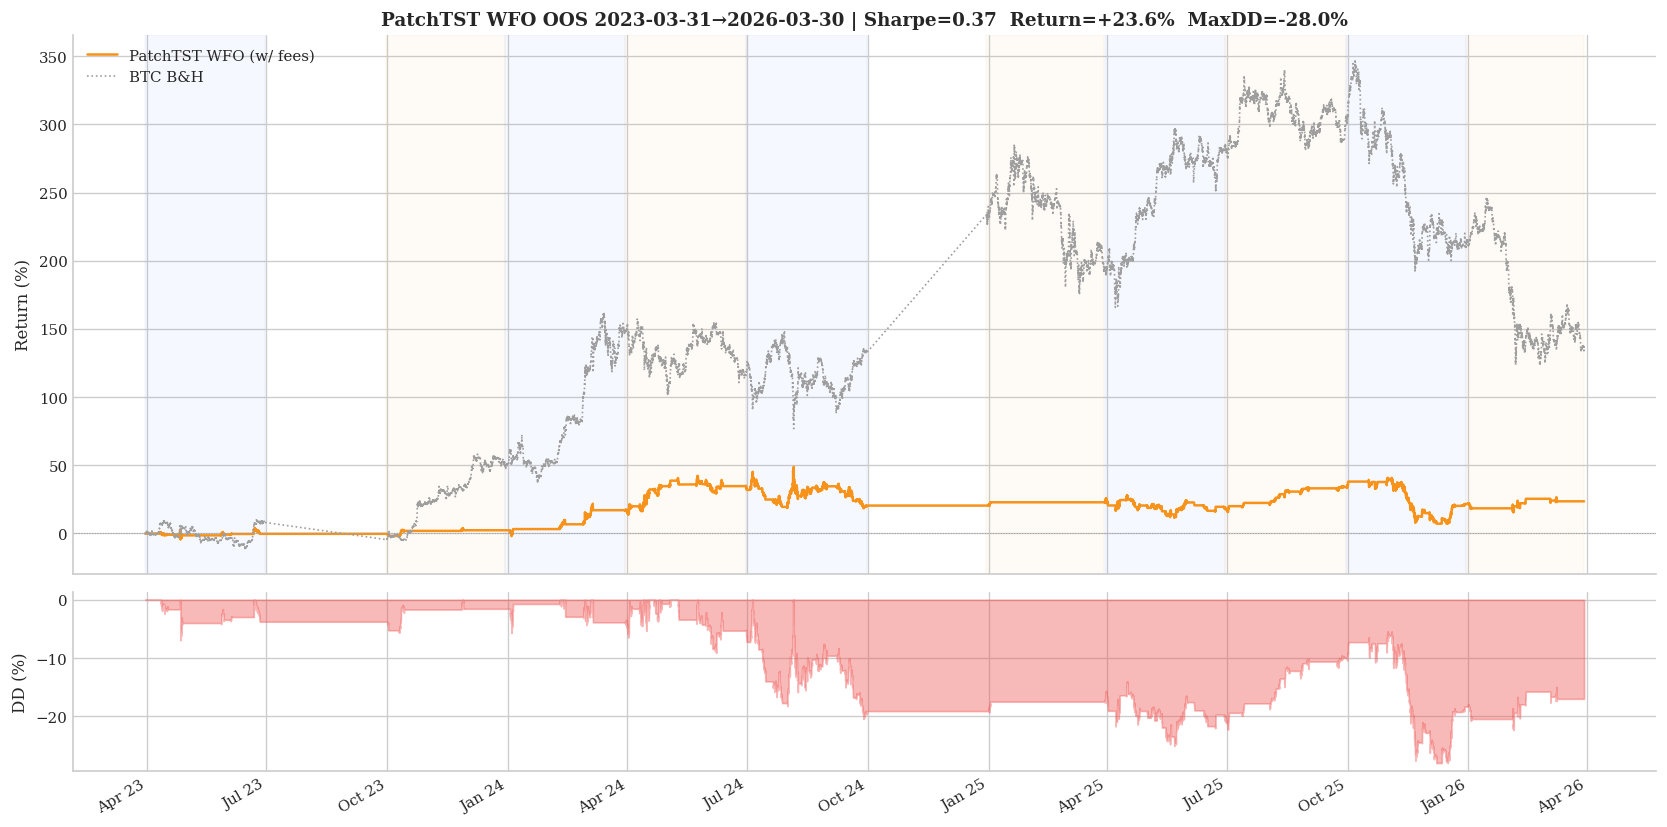

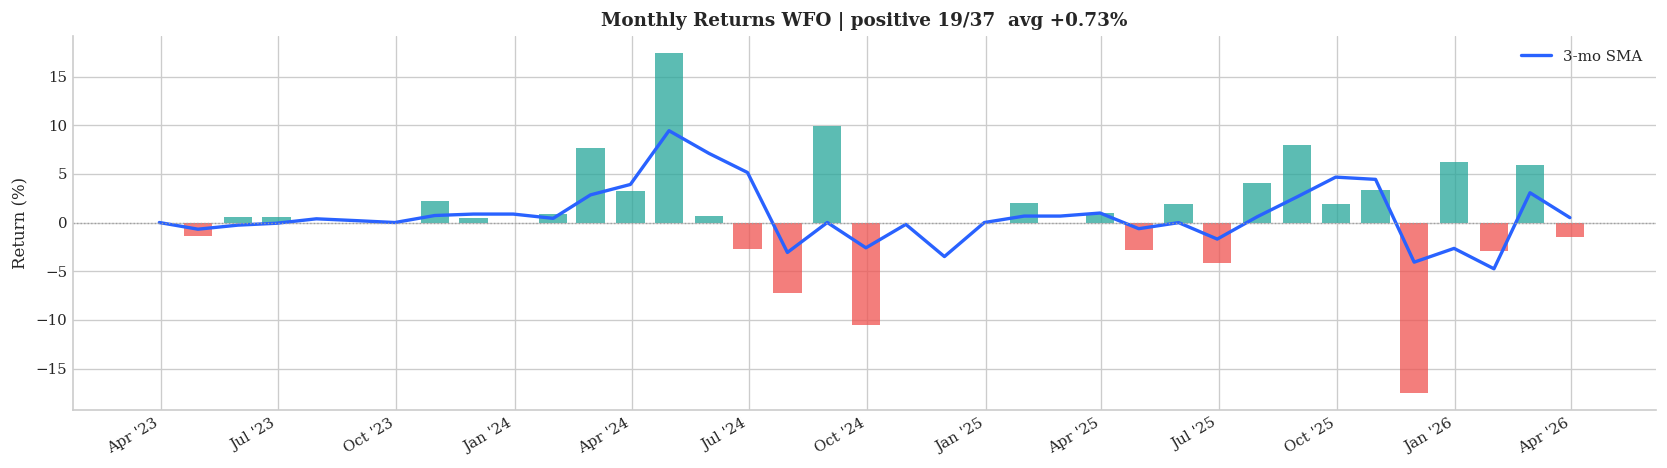

In [26]:
bh_close = df.loc[all_idx,'close'].values
bh = (bh_close/bh_close[0]-1)*100

fig,(ax1,ax2)=plt.subplots(2,1,figsize=(14,7),height_ratios=[3,1],sharex=True)
ax1.plot(all_idx,(eq_stitched-1)*100,color=ACCENT,lw=1.5,label='PatchTST WFO (w/ fees)')
ax1.plot(all_idx,bh,color=GREY,lw=1.0,ls=':',label='BTC B&H')
ax1.axhline(0,color=GREY,lw=0.6,ls=':')
# shade fold OOS windows
for i,r in enumerate(wfo_results):
    ax1.axvspan(r['fold_info']['oos_start'],r['fold_info']['oos_end'],
                alpha=0.04,color=BLUE if i%2==0 else ACCENT)
ax1.set_ylabel('Return (%)'); ax1.legend()
ax1.set_title(f'PatchTST WFO OOS {all_idx.min().date()}→{all_idx.max().date()} | '
              f'Sharpe={_sharpe(eq_stitched):.2f}  Return={eq_stitched[-1]-1:+.1%}  '
              f'MaxDD={_maxdd(eq_stitched):.1%}',fontweight='bold')
pk=np.maximum.accumulate(eq_stitched); dd=(eq_stitched-pk)/pk*100
ax2.fill_between(all_idx,dd,0,color=RED,alpha=0.4); ax2.set_ylabel('DD (%)')
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.setp(ax2.xaxis.get_majorticklabels(),rotation=30,ha='right')
fig.tight_layout(); fig.savefig(ARTS_DIR/'01_equity_drawdown.png'); plt.show()

eqs=pd.Series(eq_stitched,index=all_idx); mret=eqs.resample('ME').last().pct_change().fillna(0)*100
fig,ax=plt.subplots(figsize=(14,4))
ax.bar(mret.index,mret.values,color=[GREEN if r>=0 else RED for r in mret],width=22,alpha=0.75)
ax.plot(mret.index,mret.rolling(3,min_periods=1).mean(),color=BLUE,lw=2,label='3-mo SMA')
ax.axhline(0,color=GREY,lw=0.8,ls=':'); ax.set_ylabel('Return (%)'); ax.legend()
ax.set_title(f'Monthly Returns WFO | positive {int((mret>0).sum())}/{len(mret)}  avg {mret.mean():+.2f}%',fontweight='bold')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.setp(ax.xaxis.get_majorticklabels(),rotation=30,ha='right')
fig.tight_layout(); fig.savefig(ARTS_DIR/'02_monthly_returns.png'); plt.show()


## 11 · Save artifacts

In [27]:
# ── Save WFO OOS probs (full range) ───────────────────────────────────────────
np.save(ARTS_DIR/'wfo_probs.npy',  all_pup)
np.save(ARTS_DIR/'wfo_pdown.npy',  all_pdn)
np.save(ARTS_DIR/'wfo_index.npy',
        all_idx.astype('datetime64[ns]').astype(np.int64).values)

# ── OOS subset matching v1 reference window (2024-06-01+) ─────────────────────
ref_mask = all_idx >= OOS_REF_START
oos_probs_ref = all_pup[ref_mask]; oos_pdn_ref = all_pdn[ref_mask]
oos_idx_ref   = all_idx[ref_mask]
np.save(ARTS_DIR/'oos_probs.npy', oos_probs_ref)
np.save(ARTS_DIR/'oos_pdown.npy', oos_pdn_ref)
np.save(ARTS_DIR/'oos_index.npy',
        oos_idx_ref.astype('datetime64[ns]').astype(np.int64).values)

# ── Save last fold model ───────────────────────────────────────────────────────
if wfo_results:
    torch.save(wfo_results[-1].get('best_state', {}), ARTS_DIR/'model_lastfold.pt')

# ── Per-fold params summary ────────────────────────────────────────────────────
fold_params = [{'fold':r['fold'],**r['best_params'],'val_auc':r['val_auc'],'best_epoch':r['best_epoch']}
               for r in wfo_results]

def _bt_metrics(eq, tlist):
    if not tlist: return {'n_trades':0,'n_long':0,'n_short':0,'win_rate':0,'total_ret':0,'sharpe':0,'maxdd':0}
    t=pd.DataFrame(tlist)
    return {'n_trades':len(t),'n_long':int((t['direction']=='long').sum()),
            'n_short':int((t['direction']=='short').sum()),
            'win_rate':round(float((t['net']>0).mean()),4),
            'total_ret':round(float(eq[-1]-1),4),
            'sharpe':round(_sharpe(eq),4),'maxdd':round(_maxdd(eq),4)}

all_trades=[t for r in wfo_results for t in r['trades']]
results={
    'notebook':'04_patchtst_v2_wfo','created':pd.Timestamp.now().isoformat(),
    'model':'PatchTST WFO (3m val / 3m OOS, expanding train)',
    'wfo':{'base_train_end':str(BASE_TRAIN_END.date()),
           'fold_val_months':FOLD_VAL_MONTHS,'fold_oos_months':FOLD_OOS_MONTHS,
           'n_folds':len(folds),'completed_folds':len(wfo_results)},
    'wfo_oos_range':{'start':str(all_idx.min().date()),'end':str(all_idx.max().date())},
    'oos_ref_range':{'start':str(OOS_REF_START.date()),'end':str(oos_idx_ref.max().date())},
    'backtest_stitched':_bt_metrics(eq_stitched, all_trades),
    'fold_params':fold_params,
    'artifacts':{'wfo_probs':'wfo_probs.npy','wfo_index':'wfo_index.npy',
                 'oos_probs':'oos_probs.npy','oos_index':'oos_index.npy','model':'model_lastfold.pt'},
}
with open(ARTS_DIR/'results.json','w') as f: json.dump(results,f,indent=2)
print(f'Artifacts saved → {ARTS_DIR}')
print(f'WFO OOS: {len(all_idx):,} bars ({all_idx.min().date()}→{all_idx.max().date()})')
print(f'OOS ref: {len(oos_idx_ref):,} bars ({OOS_REF_START.date()}→{oos_idx_ref.max().date()})')


Artifacts saved → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/notebooks_v2/05_patchtst_v2
WFO OOS: 21,888 bars (2023-03-31→2026-03-30)
OOS ref: 13,825 bars (2024-06-01→2026-03-30)


## 11 · Regime Analysis

=== Regime Performance Breakdown (stitched WFO OOS) ===
                  Bars  Return  Sharpe Sortino   MaxDD   BH_Ret    Alpha
Period                                                                  
Full WFO OOS     21888  +23.6%   0.368   0.222  -28.0%  +135.4%  -111.8%
Regime 1 — Chop   2905  -11.3%  -0.969  -0.803  -20.4%    -3.2%    -8.1%
Regime 2 — Bull   7320  +15.3%   1.088   0.685  -12.9%   +16.4%    -1.0%
Regime 3 — Bear   3577  -11.4%  -1.155  -0.740  -23.9%   -39.6%   +28.2%


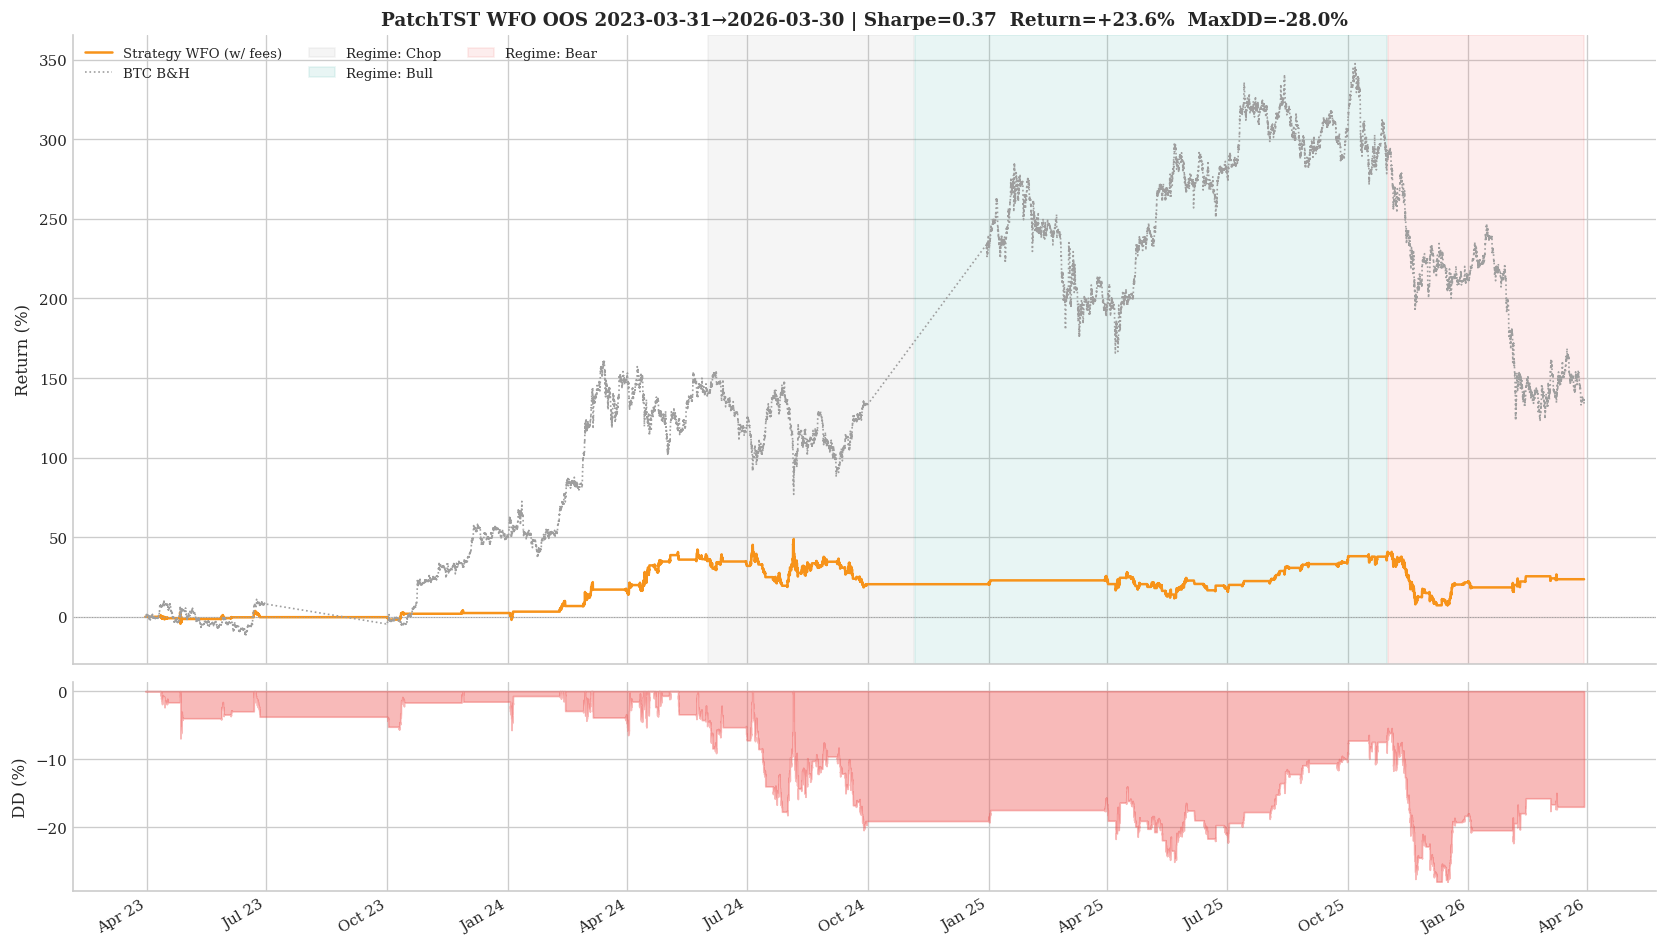

In [28]:
print('=== Regime Performance Breakdown (stitched WFO OOS) ===')
reg_tbl = _regime_table(eq_stitched, all_idx, df.loc[all_idx,'close'].values)
print(reg_tbl.to_string())

fig,(ax1,ax2)=plt.subplots(2,1,figsize=(14,8),height_ratios=[3,1],sharex=True)
ax1.plot(all_idx,(eq_stitched-1)*100,color=ACCENT,lw=1.5,label='Strategy WFO (w/ fees)')
ax1.plot(all_idx,bh,color=GREY,lw=1.0,ls=':',label='BTC B&H')
for rname,(rs,re),rc in [('Chop',REGIME_CHOP,'#9E9E9E'),('Bull',REGIME_BULL,'#26A69A'),('Bear',REGIME_BEAR,'#EF5350')]:
    ax1.axvspan(rs,min(re,all_idx[-1]),alpha=0.10,color=rc,label=f'Regime: {rname}')
ax1.axhline(0,color=GREY,lw=0.6,ls=':'); ax1.set_ylabel('Return (%)'); ax1.legend(fontsize=8,ncol=3)
ax1.set_title(f'PatchTST WFO OOS {all_idx.min().date()}→{all_idx.max().date()} | '
              f'Sharpe={_sharpe(eq_stitched):.2f}  Return={eq_stitched[-1]-1:+.1%}  MaxDD={_maxdd(eq_stitched):.1%}',
              fontweight='bold')
pk=np.maximum.accumulate(eq_stitched); dd=(eq_stitched-pk)/pk*100
ax2.fill_between(all_idx,dd,0,color=RED,alpha=0.4); ax2.set_ylabel('DD (%)')
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.setp(ax2.xaxis.get_majorticklabels(),rotation=30,ha='right')
fig.tight_layout(); fig.savefig(ARTS_DIR/'01_equity_regime.png'); plt.show()
